# Gráficos — Tempo (LED-36) e Geografia (LED-37)

Consultas de [`analytics/01_consultas_tempo.sql`](01_consultas_tempo.sql) e
[`analytics/02_consultas_geografia.sql`](02_consultas_geografia.sql), plotadas para apoiar
os slides de apresentação (LED-44). Conecta direto no `warehouse.duckdb` e consulta só o
modelo final (`fato_corrida` + dimensões).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

con = duckdb.connect('../warehouse.duckdb', read_only=True)

# Paleta categórica validada (ordem fixa, não ciclada) - ver skill de dataviz do projeto
BLUE = '#2a78d6'    # baseline / dia útil / fora de pico
ORANGE = '#eb6834'  # destaque / fim de semana / pico
TEXT = '#0b0b0b'
MUTED = '#52514e'
GRID = '#e5e4e0'

# Rampa sequencial (um hue só, claro->escuro) para o heatmap de fluxo entre boroughs
SEQ_BLUE = LinearSegmentedColormap.from_list(
    'seq_blue', ['#cde2fb', '#9ec5f4', '#5598e7', '#2a78d6', '#184f95', '#0d366b']
)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': MUTED,
    'axes.labelcolor': TEXT,
    'text.color': TEXT,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.size': 11,
})

def style_ax(ax, grid_axis='y'):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def milhar(x, _=None):
    return f'{int(x):,}'.replace(',', '.')

## Tempo (LED-36)

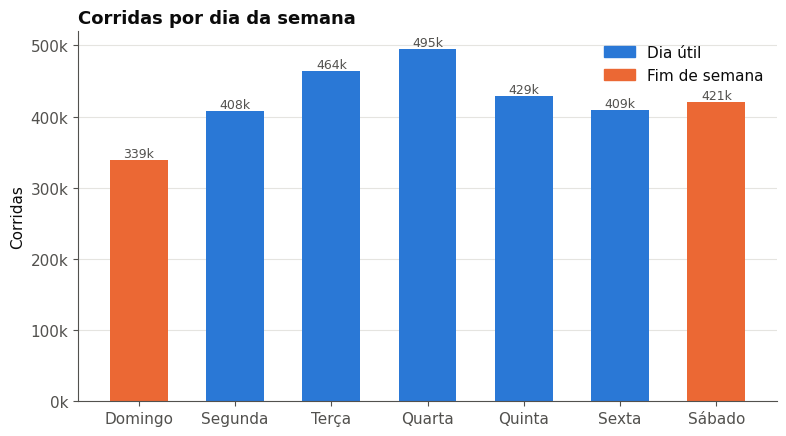

In [2]:
df = con.execute('''
    SELECT d.dia_semana_nome, d.dia_semana_num, d.fim_de_semana, COUNT(*) AS qtd_corridas
    FROM fato_corrida f
    JOIN dim_data d ON d.id_data_sk = f.id_data_embarque_sk
    GROUP BY d.dia_semana_nome, d.dia_semana_num, d.fim_de_semana
    ORDER BY d.dia_semana_num
''').fetchdf()

colors = [ORANGE if fs else BLUE for fs in df['fim_de_semana']]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(df['dia_semana_nome'], df['qtd_corridas'], color=colors, width=0.6)
ax.set_title('Corridas por dia da semana', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Corridas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(ax)
for b in bars:
    ax.annotate(f'{b.get_height()/1000:.0f}k', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
ax.legend(handles=[Patch(color=BLUE, label='Dia útil'), Patch(color=ORANGE, label='Fim de semana')],
          frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

Quarta é o dia de maior volume; fins de semana têm menos corridas, mas as mais longas em duração média (ver tabela de `01_consultas_tempo.sql`).

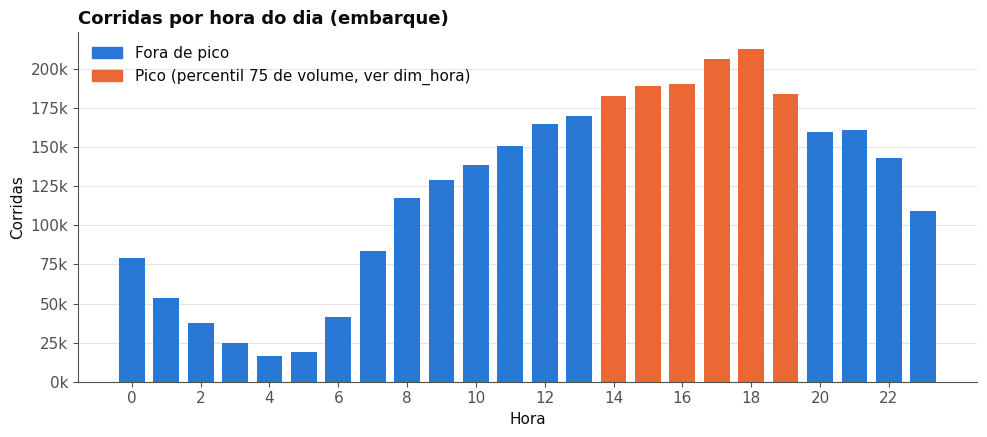

In [3]:
df = con.execute('''
    SELECT h.id_hora_sk AS hora, h.turno, h.faixa_pico, COUNT(*) AS qtd_corridas
    FROM fato_corrida f
    JOIN dim_hora h ON h.id_hora_sk = f.id_hora_embarque_sk
    GROUP BY h.id_hora_sk, h.turno, h.faixa_pico
    ORDER BY h.id_hora_sk
''').fetchdf()

colors = [ORANGE if p else BLUE for p in df['faixa_pico']]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(df['hora'], df['qtd_corridas'], color=colors, width=0.75)
ax.set_title('Corridas por hora do dia (embarque)', loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora')
ax.set_ylabel('Corridas')
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(ax)
ax.legend(handles=[Patch(color=BLUE, label='Fora de pico'), Patch(color=ORANGE, label='Pico (percentil 75 de volume, ver dim_hora)')],
          frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

Pico real cai entre 14h e 19h — vespertino/começo da noite, não o rush-hour matinal clássico.

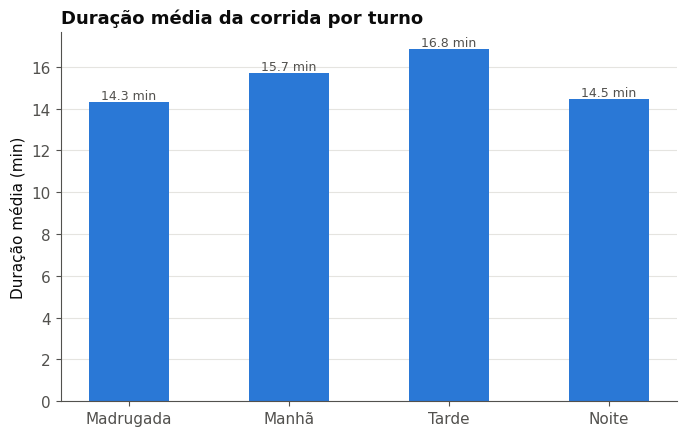

In [4]:
df = con.execute('''
    SELECT h.turno, COUNT(*) AS qtd_corridas, ROUND(AVG(f.trip_duration_minutes), 2) AS duracao_media_min
    FROM fato_corrida f JOIN dim_hora h ON h.id_hora_sk = f.id_hora_embarque_sk
    GROUP BY h.turno
''').fetchdf()
ordem = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
df['turno'] = pd.Categorical(df['turno'], categories=ordem, ordered=True)
df = df.sort_values('turno')

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(df['turno'], df['duracao_media_min'], color=BLUE, width=0.5)
ax.set_title('Duração média da corrida por turno', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Duração média (min)')
style_ax(ax)
for b in bars:
    ax.annotate(f'{b.get_height():.1f} min', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

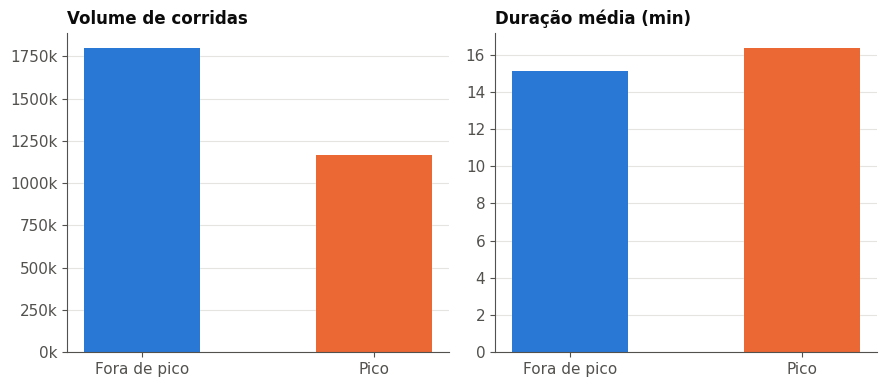

In [5]:
df = con.execute('''
    SELECT h.faixa_pico, COUNT(*) AS qtd_corridas, ROUND(AVG(f.trip_duration_minutes), 2) AS duracao_media_min
    FROM fato_corrida f JOIN dim_hora h ON h.id_hora_sk = f.id_hora_embarque_sk
    GROUP BY h.faixa_pico
    ORDER BY h.faixa_pico
''').fetchdf()
df['label'] = df['faixa_pico'].map({False: 'Fora de pico', True: 'Pico'})
cores = [BLUE, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(df['label'], df['qtd_corridas'], color=cores, width=0.5)
axes[0].set_title('Volume de corridas', loc='left', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(axes[0])

axes[1].bar(df['label'], df['duracao_media_min'], color=cores, width=0.5)
axes[1].set_title('Duração média (min)', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[1])

plt.tight_layout()
plt.show()

Pico concentra mais corridas e também dura mais em média — coerente com trânsito mais pesado no fim de tarde.

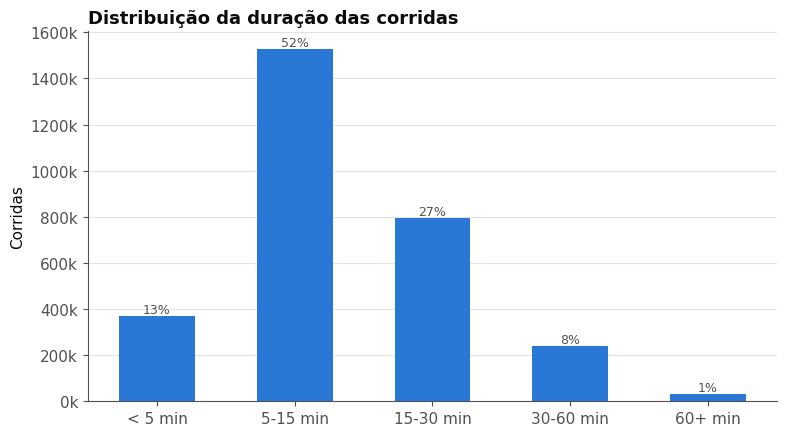

In [6]:
df = con.execute('''
    SELECT CASE
        WHEN trip_duration_minutes < 5  THEN '< 5 min'
        WHEN trip_duration_minutes < 15 THEN '5-15 min'
        WHEN trip_duration_minutes < 30 THEN '15-30 min'
        WHEN trip_duration_minutes < 60 THEN '30-60 min'
        ELSE '60+ min'
    END AS faixa_duracao,
    COUNT(*) AS qtd_corridas
    FROM fato_corrida
    GROUP BY faixa_duracao
''').fetchdf()
ordem = ['< 5 min', '5-15 min', '15-30 min', '30-60 min', '60+ min']
df['faixa_duracao'] = pd.Categorical(df['faixa_duracao'], categories=ordem, ordered=True)
df = df.sort_values('faixa_duracao')
total = df['qtd_corridas'].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(df['faixa_duracao'], df['qtd_corridas'], color=BLUE, width=0.55)
ax.set_title('Distribuição da duração das corridas', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('Corridas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
style_ax(ax)
for b in bars:
    pct = b.get_height() / total * 100
    ax.annotate(f'{pct:.0f}%', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

## Geografia (LED-37)

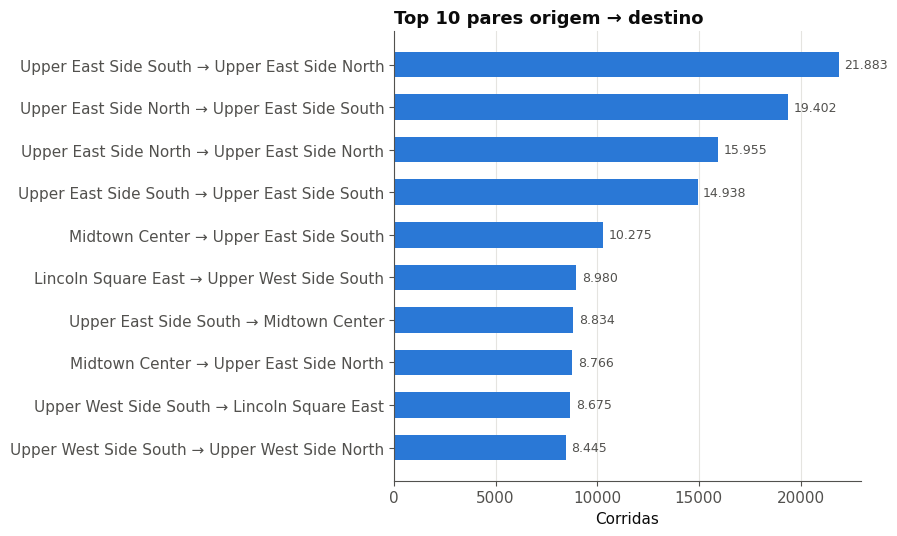

In [7]:
df = con.execute('''
    SELECT z_pu.zone AS zona_origem, z_do.zone AS zona_destino, COUNT(*) AS qtd_corridas
    FROM fato_corrida f
    JOIN dim_zona z_pu ON z_pu.id_zona_sk = f.id_zona_pu_sk
    JOIN dim_zona z_do ON z_do.id_zona_sk = f.id_zona_do_sk
    GROUP BY z_pu.zone, z_do.zone
    ORDER BY qtd_corridas DESC
    LIMIT 10
''').fetchdf()
df['par'] = df['zona_origem'] + ' → ' + df['zona_destino']
df = df.sort_values('qtd_corridas')

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(df['par'], df['qtd_corridas'], color=BLUE, height=0.6)
ax.set_title('Top 10 pares origem → destino', loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('Corridas')
style_ax(ax, grid_axis='x')
for b in bars:
    ax.annotate(milhar(b.get_width()), (b.get_width(), b.get_y() + b.get_height()/2),
                ha='left', va='center', fontsize=9, color=MUTED, xytext=(4, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

Os 4 pares mais frequentes são todos dentro do Upper East Side — viagens curtas e recorrentes no mesmo bairro.

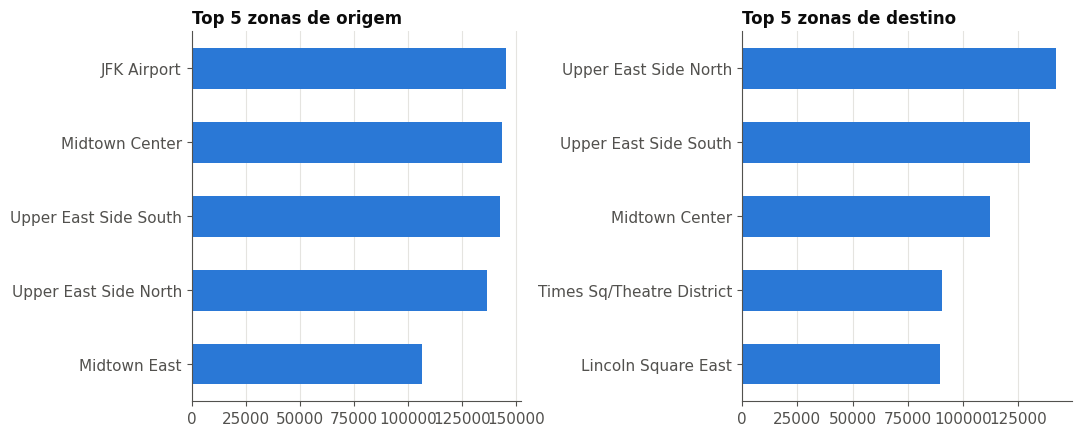

In [8]:
df_o = con.execute('''
    SELECT z.zone, COUNT(*) AS qtd FROM fato_corrida f
    JOIN dim_zona z ON z.id_zona_sk = f.id_zona_pu_sk
    GROUP BY z.zone ORDER BY qtd DESC LIMIT 5
''').fetchdf().sort_values('qtd')

df_d = con.execute('''
    SELECT z.zone, COUNT(*) AS qtd FROM fato_corrida f
    JOIN dim_zona z ON z.id_zona_sk = f.id_zona_do_sk
    GROUP BY z.zone ORDER BY qtd DESC LIMIT 5
''').fetchdf().sort_values('qtd')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(df_o['zone'], df_o['qtd'], color=BLUE, height=0.55)
axes[0].set_title('Top 5 zonas de origem', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[0], grid_axis='x')

axes[1].barh(df_d['zone'], df_d['qtd'], color=BLUE, height=0.55)
axes[1].set_title('Top 5 zonas de destino', loc='left', fontsize=12, fontweight='bold')
style_ax(axes[1], grid_axis='x')

plt.tight_layout()
plt.show()

JFK Airport só aparece como origem no top 5, não como destino — assimetria esperada (quem desembarca lá em geral não pega outro táxi de volta pelo mesmo padrão de origem).

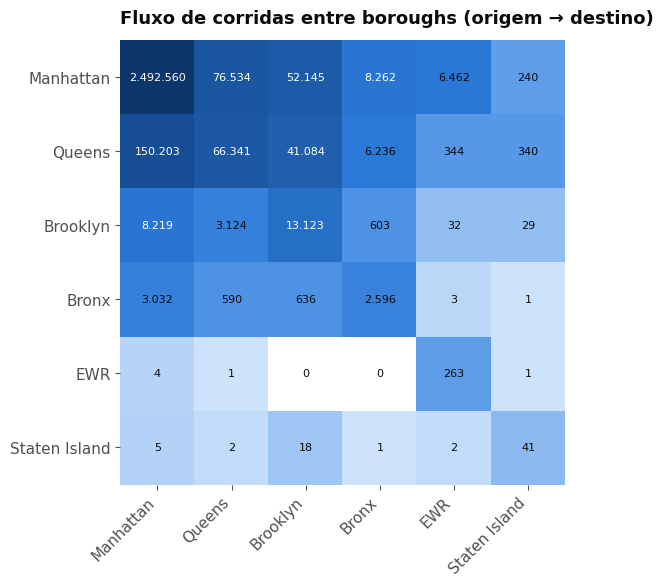

In [9]:
df = con.execute('''
    SELECT z_pu.borough AS origem, z_do.borough AS destino, COUNT(*) AS qtd
    FROM fato_corrida f
    JOIN dim_zona z_pu ON z_pu.id_zona_sk = f.id_zona_pu_sk
    JOIN dim_zona z_do ON z_do.id_zona_sk = f.id_zona_do_sk
    WHERE z_pu.borough != 'Desconhecido' AND z_do.borough != 'Desconhecido'
    GROUP BY z_pu.borough, z_do.borough
''').fetchdf()

matriz = df.pivot(index='origem', columns='destino', values='qtd').fillna(0)
ordem_boroughs = matriz.sum(axis=1).sort_values(ascending=False).index
matriz = matriz.loc[ordem_boroughs, ordem_boroughs]

# Escala LOG na cor (não no valor): Manhattan->Manhattan (2,49M) é ~30x maior que o segundo
# fluxo mais forte - uma escala linear apagaria toda a variação entre os demais pares.
# Os números exibidos continuam os valores reais, só a cor de fundo é logarítmica.
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=max(matriz.values.min(), 1), vmax=matriz.values.max())

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(matriz.values, cmap=SEQ_BLUE, norm=norm)
ax.set_xticks(range(len(matriz.columns)))
ax.set_xticklabels(matriz.columns, rotation=45, ha='right')
ax.set_yticks(range(len(matriz.index)))
ax.set_yticklabels(matriz.index)
ax.set_title('Fluxo de corridas entre boroughs (origem → destino)', loc='left', fontsize=13, fontweight='bold', pad=12)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        val = matriz.values[i, j]
        cor_texto = 'white' if norm(max(val, 1)) > 0.6 else TEXT
        ax.text(j, i, milhar(val), ha='center', va='center', fontsize=8, color=cor_texto)

for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

Manhattan→Manhattan domina (2,49M corridas) por volume absoluto tão maior que o resto que esconde o segundo padrão mais forte no mapa: Queens→Manhattan (150k), puxado por JFK/LaGuardia.

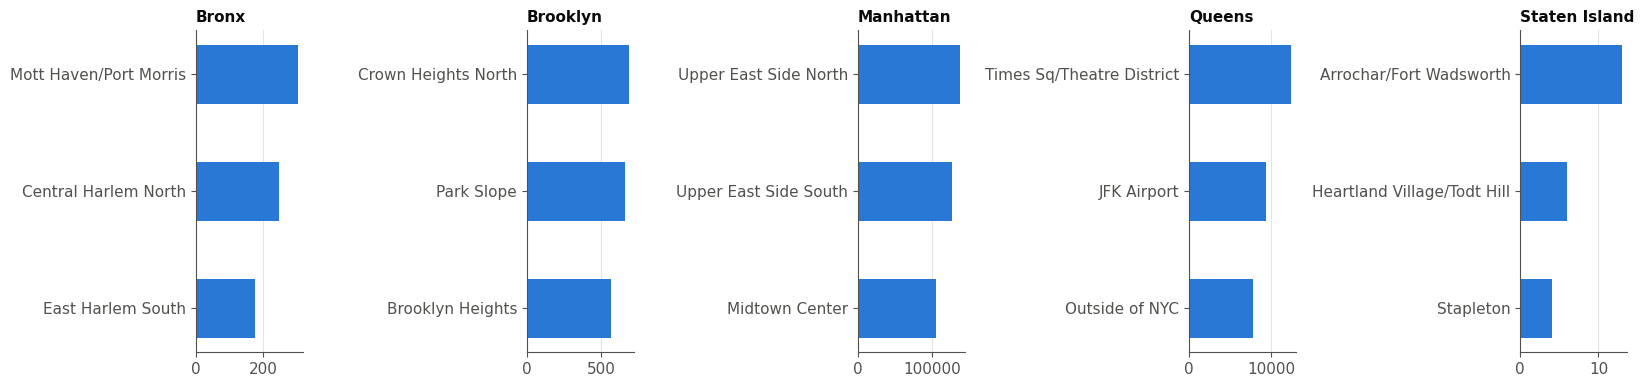

In [10]:
df = con.execute('''
    WITH ranked AS (
        SELECT z_pu.borough AS borough_origem, z_do.zone AS zona_destino, COUNT(*) AS qtd,
               ROW_NUMBER() OVER (PARTITION BY z_pu.borough ORDER BY COUNT(*) DESC) AS posicao
        FROM fato_corrida f
        JOIN dim_zona z_pu ON z_pu.id_zona_sk = f.id_zona_pu_sk
        JOIN dim_zona z_do ON z_do.id_zona_sk = f.id_zona_do_sk
        WHERE z_pu.borough NOT IN ('Desconhecido', 'EWR')
        GROUP BY z_pu.borough, z_do.zone
    )
    SELECT * FROM ranked WHERE posicao <= 3 ORDER BY borough_origem, posicao
''').fetchdf()

boroughs = sorted(df['borough_origem'].unique())
fig, axes = plt.subplots(1, len(boroughs), figsize=(3.3 * len(boroughs), 4))
for ax, borough in zip(axes, boroughs):
    sub = df[df['borough_origem'] == borough].sort_values('qtd')
    ax.barh(sub['zona_destino'], sub['qtd'], color=BLUE, height=0.5)
    ax.set_title(borough, loc='left', fontsize=11, fontweight='bold')
    style_ax(ax, grid_axis='x')
plt.tight_layout()
plt.show()

Cada borough tem seu próprio padrão local de destino preferido — só Manhattan concentra volumes na casa das centenas de milhar; os demais ficam na casa das centenas/milhares.

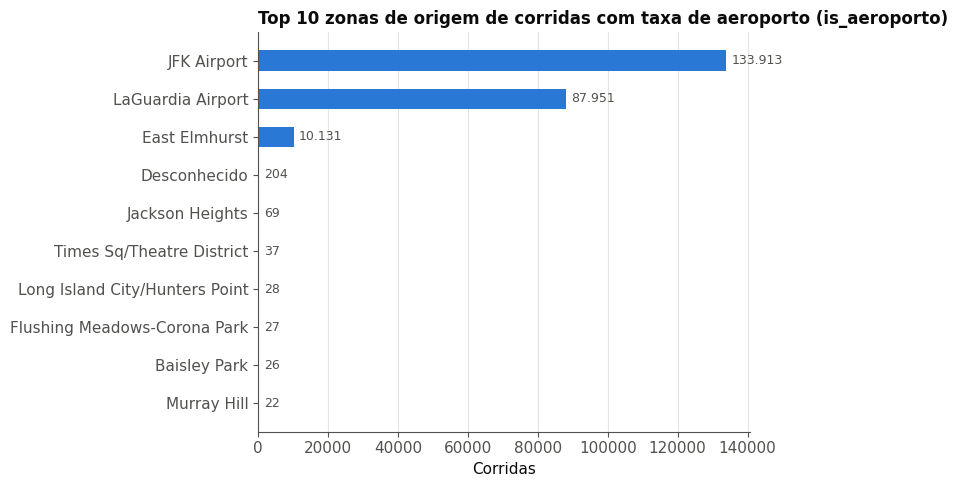

In [11]:
df = con.execute('''
    SELECT z.zone, COUNT(*) AS qtd
    FROM fato_corrida f JOIN dim_zona z ON z.id_zona_sk = f.id_zona_pu_sk
    WHERE f.is_aeroporto
    GROUP BY z.zone ORDER BY qtd DESC LIMIT 10
''').fetchdf().sort_values('qtd')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df['zone'], df['qtd'], color=BLUE, height=0.55)
ax.set_title('Top 10 zonas de origem de corridas com taxa de aeroporto (is_aeroporto)', loc='left', fontsize=12, fontweight='bold')
ax.set_xlabel('Corridas')
style_ax(ax, grid_axis='x')
for b in bars:
    ax.annotate(milhar(b.get_width()), (b.get_width(), b.get_y() + b.get_height()/2),
                ha='left', va='center', fontsize=9, color=MUTED, xytext=(4, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

JFK e LaGuardia concentram quase toda a taxa de aeroporto; East Elmhurst aparece porque geograficamente cobre parte do LaGuardia (docs/regras_limpeza.md item 8).